<a href="https://colab.research.google.com/github/amyahespanol/Amyah-Espanol-Statistical-Theory-APM1111/blob/main/FA6_Espanol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

-Population Statistics
Population Mean (mu): 12.0
Population Variance (sigma^2): 6.0

-All 9 Possible Samples
   Value 1  Value 2  Sample Mean (x_bar)
0        9        9                  9.0
1        9       12                 10.5
2        9       15                 12.0
3       12        9                 10.5
4       12       12                 12.0
5       12       15                 13.5
6       15        9                 12.0
7       15       12                 13.5
8       15       15                 15.0


-Sampling Distribution
   x_bar    p_xbar
0    9.0  0.111111
1   10.5  0.222222
2   12.0  0.333333
3   13.5  0.222222
4   15.0  0.111111


-Verification
Mean of Sample Means (mu_x_bar): 11.999999999999998
Is mu_xbar == mu? True
Variance of Sample Means (sigma_x_bar^2): 3.0
Is sigma_xbar^2 == sigma^2 / n? True


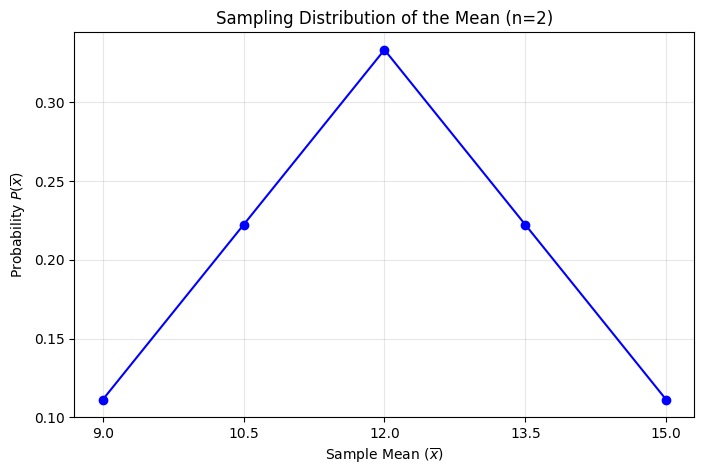

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

population = np.array([9, 12, 15])
n = 2  # sample size

mu = np.mean(population)
sigma_sq = np.var(population)

print(f"-Population Statistics")
print(f"Population Mean (mu): {mu}")
print(f"Population Variance (sigma^2): {sigma_sq}\n")

#List all possible samples of size n=2 with replacement
#Cartesian product
samples = list(product(population, repeat=n))
sample_means = [np.mean(s) for s in samples]

# Create table
df_samples = pd.DataFrame(samples, columns=['Value 1', 'Value 2'])
df_samples['Sample Mean (x_bar)'] = sample_means

print(f"-All {len(samples)} Possible Samples")
print(df_samples)
print("\n")

# Sampling Distribution of the Mean

dist = df_samples['Sample Mean (x_bar)'].value_counts(normalize=True).sort_index().reset_index()
dist.columns = ['x_bar', 'p_xbar']

print(f"-Sampling Distribution")
print(dist)
print("\n")

# Verify Theorems
mu_xbar = np.sum(dist['x_bar'] * dist['p_xbar'])
var_xbar = np.sum(((dist['x_bar'] - mu_xbar)**2) * dist['p_xbar'])

print(f"-Verification")
print(f"Mean of Sample Means (mu_x_bar): {mu_xbar}")
print(f"Is mu_xbar == mu? {np.isclose(mu_xbar, mu)}")

print(f"Variance of Sample Means (sigma_x_bar^2): {var_xbar}")
print(f"Is sigma_xbar^2 == sigma^2 / n? {np.isclose(var_xbar, sigma_sq/n)}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(dist['x_bar'], dist['p_xbar'], marker='o', linestyle='-', color='blue')
plt.title(f'Sampling Distribution of the Mean (n={n})')
plt.xlabel(r'Sample Mean ($\overline{x}$)')
plt.ylabel(r'Probability $P(\overline{x})$')
plt.grid(True, alpha=0.3)
plt.xticks(dist['x_bar'])
plt.show()